In [1]:
from IPython.display import Image, HTML, display
image_path = "Logos.jpeg"

img_html = Image(url=image_path, width=800)._repr_html_()

centered_image_html = f"<div style='text-align:center;'>{img_html}</div>"

display(HTML(centered_image_html))

import warnings
warnings.filterwarnings('ignore')

<div style="text-align:center"; font-size: 32px;>
    
# Geospatial data analysis

</div>

**Author:** Naziru Halilu


<span style="font-size:120%">

In this part of the class, we will work with the downloaded Sentinel-2 image. First, we will create and visualize the NDVI vegetation index. Then, we will read the downloaded CSV file of the 2017 time series and show how to generate time series graphs for different plots or crops. Finally, we will analyze and discuss the differences between these time series.
</br>
This activity seeks to enable students to:
</br>
- Load and view a satellite image.
- Create a vegetation index.
- Generate time series for various crops.
- Export the results.
</span>

## Import libraries

In [2]:
import os
import pandas as pd
import geopandas as gpd
import rasterio
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# View the working directory
os.getcwd()

In [ ]:
# Show the files inside the directory
os.listdir()

## Load and view a satellite image

In [3]:
src = rasterio.open('Sentinel2_Composite_2017.tif')

In [4]:
# Useful attributes
print('Rows and columns: ',src.shape)
print('Number of bands: ',src.count)
print('Reference system: ',src.crs)

Rows and columns:  (785, 1105)
Number of bands:  26
Reference system:  EPSG:25830


In [5]:
try:
   band_descriptions = [src.descriptions[i-1] for i in src.indexes]
   print(f"Band's description (if exist): {band_descriptions}")
except IndexError:
   print("No descriptions availables")

Band's description (if exist): ['B1', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B9', 'B11', 'B12', 'AOT', 'WVP', 'SCL', 'TCI_R', 'TCI_G', 'TCI_B', 'MSK_CLDPRB', 'MSK_SNWPRB', 'QA10', 'QA20', 'QA60', 'MSK_CLASSI_OPAQUE', 'MSK_CLASSI_CIRRUS', 'MSK_CLASSI_SNOW_ICE']


## Color composition

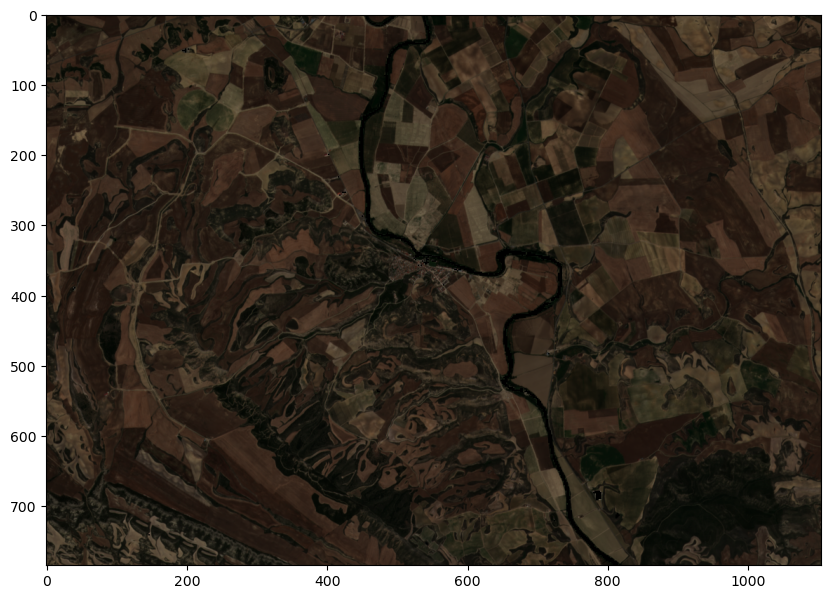

In [6]:
# Read Red band
band_red = src.read(4)
# Read green band
band_green = src.read(3)
# Read blue band
band_blue = src.read(2)
    
# Lee los metadatos y la información de la proyección (útil para guardar)
metadata = src.meta

# Apply color stretch 
def color_stretch(band, min_val, max_val):
    # Consider the maximum and minimum possible values to avoid outliers
    band = np.clip(band, min_val, max_val)
    # Scale from 0 to 255 (for display)
    band_stretched = ((band - min_val) / (max_val - min_val)) * 255
    return band_stretched.astype(np.uint8)

# Defines the cut-off values. 
min_clip = 0  
max_clip = 1

red_stretched = color_stretch(band_red, min_clip, max_clip)
green_stretched = color_stretch(band_green, min_clip, max_clip)
blue_stretched = color_stretch(band_blue, min_clip, max_clip)

# Stack the bands for display
# The final stacking order should be (Red, Green, Blue)
rgb_composite = np.dstack((red_stretched, green_stretched, blue_stretched))

# Show
plt.figure(figsize=(10, 10))
plt.imshow(rgb_composite)
plt.show()

## NDVI calculation

In [7]:
# Read the necessary bands
band_nir = src.read(8).astype(float)
band_red = src.read(4).astype(float)
    
# Prevent division by zero: Zeros are replaced by very small values
np.seterr(divide='ignore', invalid='ignore')
    
# Apply the NDVI formula
ndvi = (band_nir - band_red) / (band_nir + band_red)


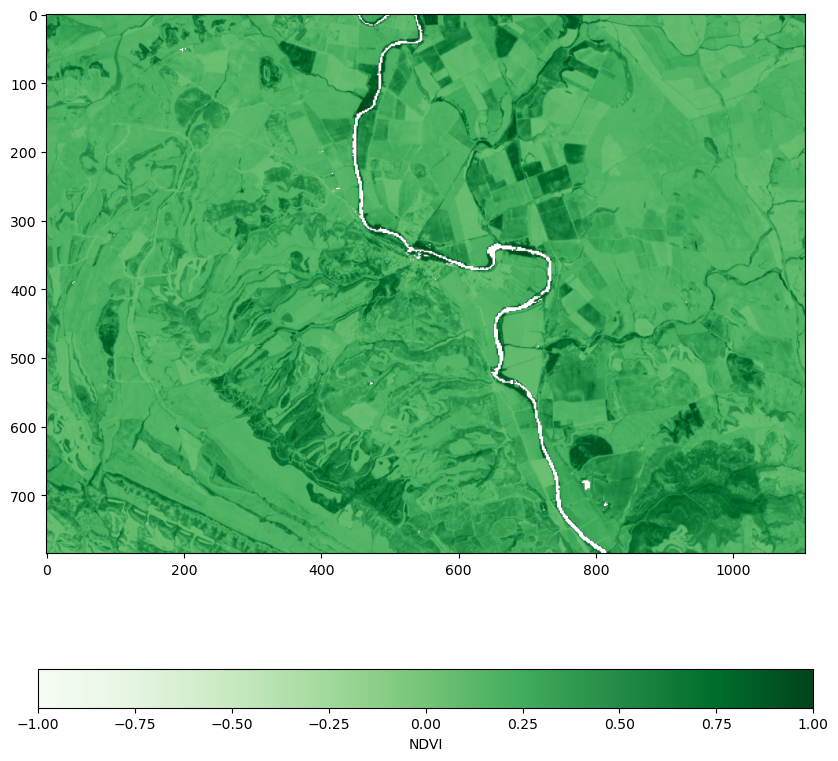

In [8]:
# Show NDVI
fig, ax = plt.subplots(figsize=(10, 10))

im = ax.imshow(ndvi, cmap='Greens', vmin=-1, vmax=1)

fig.colorbar(im, ax=ax,orientation='horizontal', label='NDVI')

plt.show()

## Time Series

In [24]:
# Read the csv file that we download from GEE
ts=pd.read_csv('Sentinel2_PlotStatistics_Raw.csv')
# ts

In [25]:
ts.columns

Index(['system:index', 'Blue', 'CLASIF_SC1', 'COEF_AUTO', 'COEF_REGAD',
       'COMARCA', 'ClasEsp', 'ClasGen', 'GEOM_AREA', 'Green', 'IDCOMARCA',
       'IDClasEsp', 'IDClasGen', 'MUNICIPIO', 'NAME_MUNIC', 'NIR', 'PARCELA',
       'POLIGONO', 'PRD_CODIGO', 'PRD_DESC_1', 'PROVINCIA', 'RE1', 'RE2',
       'RE3', 'RE4', 'RECINTO', 'REFCAT', 'Red', 'SOILTAXON1', 'SWIR1',
       'SWIR2', 'date', 'field_1', '.geo'],
      dtype='object')

In [34]:
# Split the contents of the 'date' column to get the year and month
date = (list(([x[0:7] for x in ts['date']]))) 
# Save the information in a new column
ts['Date'] = date
# Repeat the process to get only the year and month.
date = (list(([x[0:4] for x in ts['Date']])))
ts['Year'] = date
date = (list(([x[5:] for x in ts['Date']])))
ts['Month'] = date
ts

,system:index,Blue,CLASIF_SC1,COEF_AUTO,COEF_REGAD,COMARCA,ClasEsp,ClasGen,GEOM_AREA,Green,...,SOILTAXON1,SWIR1,SWIR2,date,field_1,.geo,Species,Date,Year,Month
0,20170320T105731_20170320T110651_T30TWM_0000000...,0.111733,"Arcillosa fina, Carbonática, Somera",99,0,Ribera Alta,TRIGO,TRIGO,1.225675e+09,0.161826,...,Paralithic Xeric Torriorthent,0.293070,0.188800,2017-03-20T11:09:26,35348,"{""type"":""Polygon"",""coordinates"":[[[-1.85095602...",Wheat,2017-03,2017,03
1,20170320T105731_20170320T110651_T30TWM_0000000...,0.031381,"Arcillosa fina, Mixta, Moderadamente profunda",99,0,Ribera Alta,TRIGO,TRIGO,1.225675e+09,0.064131,...,Typic Xerorthent,0.214088,0.128441,2017-03-20T11:09:26,35349,"{""type"":""MultiPolygon"",""coordinates"":[[[[-1.86...",Wheat,2017-03,2017,03
2,20170320T105731_20170320T110651_T30TWM_0000000...,0.024815,"Arcillosa fina, Mixta, Profunda",99,0,Ribera Alta,TRIGO,TRIGO,1.225675e+09,0.055732,...,Fluventic Haploxerept,0.207071,0.121811,2017-03-20T11:09:26,35350,"{""type"":""Polygon"",""coordinates"":[[[-1.86463389...",Wheat,2017-03,2017,03
3,20170320T105731_20170320T110651_T30TWM_0000000...,0.068812,"Arcillosa fina, Carbonática, Somera",54,0,Ribera Alta,SUPERFICIES FORESTALES,SUPERFICIES FORESTALES,1.225675e+09,0.097098,...,Paralithic Xeric Torriorthent,0.230154,0.132243,2017-03-20T11:09:26,35351,"{""type"":""Polygon"",""coordinates"":[[[-1.87081552...",Forest,2017-03,2017,03
4,20170320T105731_20170320T110651_T30TWM_0000000...,0.052147,"Arcillosa fina, Mixta, Moderadamente profunda",54,0,Ribera Alta,SUPERFICIES FORESTALES,SUPERFICIES FORESTALES,1.225675e+09,0.078533,...,Typic Xerorthent,0.206593,0.116579,2017-03-20T11:09:26,35352,"{""type"":""MultiPolygon"",""coordinates"":[[[[-1.85...",Forest,2017-03,2017,03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25912,20171205T110431_20171205T110426_T30TXN_0000000...,0.054237,"Arcillosa fina, Carbonática, Moderadamente pro...",2,100,Ribera Alta,GIRASOL,GIRASOL,1.225675e+09,0.079569,...,Xeric Torriorthent,0.210166,0.158656,2017-12-05T11:04:26,33826,"{""type"":""Polygon"",""coordinates"":[[[-1.77074754...",Sunflower,2017-12,2017,12
25913,20171205T110431_20171205T110426_T30TXN_0000000...,0.049086,"Arcillosa fina, Mixta, Profunda",2,100,Ribera Alta,GIRASOL,GIRASOL,1.225675e+09,0.072927,...,Pachic Calcixeroll,0.203199,0.147707,2017-12-05T11:04:26,33827,"{""type"":""Polygon"",""coordinates"":[[[-1.77187369...",Sunflower,2017-12,2017,12
25914,20171205T110431_20171205T110426_T30TXN_0000000...,0.046505,"Arcillosa fina, Mixta, Profunda",2,100,Ribera Alta,GIRASOL,GIRASOL,1.225675e+09,0.074598,...,Pachic Calcixeroll,0.199738,0.148993,2017-12-05T11:04:26,33828,"{""type"":""GeometryCollection"",""geometries"":[{""t...",Sunflower,2017-12,2017,12
25915,20171205T110431_20171205T110426_T30TXN_0000000...,0.047130,"Arcillosa fina, Mixta, Somera",2,100,Ribera Alta,GIRASOL,GIRASOL,1.225675e+09,0.070717,...,Lithic Haploxeroll,0.195161,0.151375,2017-12-05T11:04:26,33829,"{""type"":""Polygon"",""coordinates"":[[[-1.77155715...",Sunflower,2017-12,2017,12


In [35]:
# Know all the crops
list(set(ts.ClasEsp))

['GUISANTE',
 'TRIGO',
 'SUPERFICIES FORESTALES',
 'GIRASOL',
 'ALMENDROS',
 'ALFALFA',
 'VIÑA',
 'BARBECHO',
 'FRUTALES',
 'MAÍZ',
 'OLIVAR',
 'PASTOS ARBOLADOS',
 'CEBADA',
 'PASTOS ARBUSTIVOS',
 'PASTOS HERBÁCEOS',
 'HORTÍCOLA DE VERANO',
 'COLZA']

In [36]:
# Translate the crop's name and save it in a new column
ts.loc[ts.ClasEsp=='CEBADA',['Species']]='Barley'
ts.loc[ts.ClasEsp=='BARBECHO',['Species']]='Fallow'
ts.loc[ts.ClasEsp=='GIRASOL',['Species']]='Sunflower'
ts.loc[ts.ClasEsp=='COLZA',['Species']]='Rape'
ts.loc[ts.ClasEsp=='HORTÍCOLA DE VERANO',['Species']]='Summer vegetables'
ts.loc[ts.ClasEsp=='TRIGO',['Species']]='Wheat'
ts.loc[ts.ClasEsp=='PASTOS ARBUSTIVOS',['Species']]='Shrub'
ts.loc[ts.ClasEsp=='PASTOS ARBOLADOS',['Species']]='Shrub'
ts.loc[ts.ClasEsp=='PASTOS HERBÁCEOS',['Species']]='Grass'
ts.loc[ts.ClasEsp=='SUPERFICIES FORESTALES',['Species']]='Forest'
ts.loc[ts.ClasEsp=='ALMENDROS',['Species']]='Almonds'
ts.loc[ts.ClasEsp=='GUISANTE',['Species']]='Pea'
ts.loc[ts.ClasEsp=='ALFALFA',['Species']]='Alfalfa'
ts.loc[ts.ClasEsp=='FRUTALES',['Species']]='Fruit trees'
ts.loc[ts.ClasEsp=='OLIVAR',['Species']]='Olive'
ts.loc[ts.ClasEsp=='VIÑA',['Species']]='Vineyard'
ts.loc[ts.ClasEsp=='MAÍZ',['Species']]='Maize'
ts

,system:index,Blue,CLASIF_SC1,COEF_AUTO,COEF_REGAD,COMARCA,ClasEsp,ClasGen,GEOM_AREA,Green,...,SOILTAXON1,SWIR1,SWIR2,date,field_1,.geo,Species,Date,Year,Month
0,20170320T105731_20170320T110651_T30TWM_0000000...,0.111733,"Arcillosa fina, Carbonática, Somera",99,0,Ribera Alta,TRIGO,TRIGO,1.225675e+09,0.161826,...,Paralithic Xeric Torriorthent,0.293070,0.188800,2017-03-20T11:09:26,35348,"{""type"":""Polygon"",""coordinates"":[[[-1.85095602...",Wheat,2017-03,2017,03
1,20170320T105731_20170320T110651_T30TWM_0000000...,0.031381,"Arcillosa fina, Mixta, Moderadamente profunda",99,0,Ribera Alta,TRIGO,TRIGO,1.225675e+09,0.064131,...,Typic Xerorthent,0.214088,0.128441,2017-03-20T11:09:26,35349,"{""type"":""MultiPolygon"",""coordinates"":[[[[-1.86...",Wheat,2017-03,2017,03
2,20170320T105731_20170320T110651_T30TWM_0000000...,0.024815,"Arcillosa fina, Mixta, Profunda",99,0,Ribera Alta,TRIGO,TRIGO,1.225675e+09,0.055732,...,Fluventic Haploxerept,0.207071,0.121811,2017-03-20T11:09:26,35350,"{""type"":""Polygon"",""coordinates"":[[[-1.86463389...",Wheat,2017-03,2017,03
3,20170320T105731_20170320T110651_T30TWM_0000000...,0.068812,"Arcillosa fina, Carbonática, Somera",54,0,Ribera Alta,SUPERFICIES FORESTALES,SUPERFICIES FORESTALES,1.225675e+09,0.097098,...,Paralithic Xeric Torriorthent,0.230154,0.132243,2017-03-20T11:09:26,35351,"{""type"":""Polygon"",""coordinates"":[[[-1.87081552...",Forest,2017-03,2017,03
4,20170320T105731_20170320T110651_T30TWM_0000000...,0.052147,"Arcillosa fina, Mixta, Moderadamente profunda",54,0,Ribera Alta,SUPERFICIES FORESTALES,SUPERFICIES FORESTALES,1.225675e+09,0.078533,...,Typic Xerorthent,0.206593,0.116579,2017-03-20T11:09:26,35352,"{""type"":""MultiPolygon"",""coordinates"":[[[[-1.85...",Forest,2017-03,2017,03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25912,20171205T110431_20171205T110426_T30TXN_0000000...,0.054237,"Arcillosa fina, Carbonática, Moderadamente pro...",2,100,Ribera Alta,GIRASOL,GIRASOL,1.225675e+09,0.079569,...,Xeric Torriorthent,0.210166,0.158656,2017-12-05T11:04:26,33826,"{""type"":""Polygon"",""coordinates"":[[[-1.77074754...",Sunflower,2017-12,2017,12
25913,20171205T110431_20171205T110426_T30TXN_0000000...,0.049086,"Arcillosa fina, Mixta, Profunda",2,100,Ribera Alta,GIRASOL,GIRASOL,1.225675e+09,0.072927,...,Pachic Calcixeroll,0.203199,0.147707,2017-12-05T11:04:26,33827,"{""type"":""Polygon"",""coordinates"":[[[-1.77187369...",Sunflower,2017-12,2017,12
25914,20171205T110431_20171205T110426_T30TXN_0000000...,0.046505,"Arcillosa fina, Mixta, Profunda",2,100,Ribera Alta,GIRASOL,GIRASOL,1.225675e+09,0.074598,...,Pachic Calcixeroll,0.199738,0.148993,2017-12-05T11:04:26,33828,"{""type"":""GeometryCollection"",""geometries"":[{""t...",Sunflower,2017-12,2017,12
25915,20171205T110431_20171205T110426_T30TXN_0000000...,0.047130,"Arcillosa fina, Mixta, Somera",2,100,Ribera Alta,GIRASOL,GIRASOL,1.225675e+09,0.070717,...,Lithic Haploxeroll,0.195161,0.151375,2017-12-05T11:04:26,33829,"{""type"":""Polygon"",""coordinates"":[[[-1.77155715...",Sunflower,2017-12,2017,12


In [37]:
# Filter considering three different land cover
wheat=ts.loc[(ts.Species=='Wheat')]
maize=ts.loc[(ts.Species=='Maize')]
shurb=ts.loc[(ts.Species=='Shrub')]

# Print the possible identification 
print("Maize's plots ", list(set(maize.PARCELA)))
print("Wheat's plots ", list(set(wheat.PARCELA)))
print("Shrub's plots ", list(set(shurb.PARCELA)))

Maize's plots  [1297.0, 531.0, 532.0, 533.0, 798.0, 801.0, 293.0, 296.0, 808.0, 298.0, 809.0, 300.0, 810.0, 811.0, 303.0, 815.0, 1457.0, 299.0, 823.0, 1467.0, 1468.0, 1469.0, 1470.0, 1471.0, 578.0, 323.0, 324.0, 325.0, 1477.0, 330.0, 331.0, 332.0, 587.0, 335.0, 336.0, 593.0, 338.0, 339.0, 594.0, 724.0, 1234.0, 343.0, 598.0, 1245.0, 1248.0, 1257.0, 1258.0, 1259.0, 1260.0, 1133.0, 617.0, 1263.0, 1264.0, 1273.0]
Wheat's plots  [580.0, 581.0, 71.0, 74.0, 76.0, 589.0, 590.0, 591.0, 595.0, 1134.0, 1135.0, 1139.0, 1141.0, 1144.0, 1146.0, 1152.0, 136.0, 1161.0, 137.0, 1179.0, 1186.0, 1229.0, 1232.0, 1233.0, 1235.0, 1236.0, 1238.0, 1242.0, 1243.0, 1244.0, 1251.0, 1252.0, 1253.0, 1254.0, 750.0, 763.0, 764.0, 252.0, 765.0, 768.0, 769.0, 1284.0, 788.0, 790.0, 791.0, 792.0, 795.0, 798.0, 800.0, 803.0, 804.0, 805.0, 812.0, 813.0, 814.0, 816.0, 818.0, 307.0, 308.0, 310.0, 311.0, 314.0, 315.0, 316.0, 830.0, 319.0, 832.0, 833.0, 322.0, 318.0, 326.0, 327.0, 328.0, 329.0, 334.0, 338.0, 340.0, 341.0, 350.

In [38]:
# Select only one plot per land cover
selection=ts.loc[((ts.Species=='Wheat')&(ts.PARCELA==322.0))|((ts.Species=='Maize')&(ts.PARCELA==323.0))| ((ts.Species=='Shrub')&(ts.PARCELA==322.0))]
selection

,system:index,Blue,CLASIF_SC1,COEF_AUTO,COEF_REGAD,COMARCA,ClasEsp,ClasGen,GEOM_AREA,Green,...,SOILTAXON1,SWIR1,SWIR2,date,field_1,.geo,Species,Date,Year,Month
56,20170409T105651_20170409T110529_T30TXN_0000000...,0.040898,"Arcillosa fina, Mixta, Profunda",81,0,Ribera Alta,PASTOS ARBUSTIVOS,PASTOS,1.225675e+09,0.063049,...,Pachic Calcixeroll,0.222669,0.143883,2017-04-09T11:05:29,33727,"{""type"":""GeometryCollection"",""geometries"":[{""t...",Shrub,2017-04,2017,04
57,20170409T105651_20170409T110529_T30TXN_0000000...,0.059917,"Arcillosa fina, Carbonática, Moderadamente pro...",99,0,Ribera Alta,PASTOS ARBUSTIVOS,PASTOS,1.225675e+09,0.093172,...,Xeric Torriorthent,0.277509,0.208409,2017-04-09T11:05:29,33728,"{""type"":""Polygon"",""coordinates"":[[[-1.76054277...",Shrub,2017-04,2017,04
58,20170409T105651_20170409T110529_T30TXN_0000000...,0.112670,"Arcillosa fina, Carbonática, Moderadamente pro...",76,0,Ribera Alta,PASTOS ARBUSTIVOS,PASTOS,1.225675e+09,0.155026,...,Xeric Torriorthent,0.309838,0.236232,2017-04-09T11:05:29,33729,"{""type"":""MultiPolygon"",""coordinates"":[[[[-1.76...",Shrub,2017-04,2017,04
59,20170409T105651_20170409T110529_T30TXN_0000000...,0.046328,"Arcillosa fina, Carbonática, Moderadamente pro...",76,0,Ribera Alta,PASTOS ARBUSTIVOS,PASTOS,1.225675e+09,0.070933,...,Xeric Torriorthent,0.228524,0.145987,2017-04-09T11:05:29,33730,"{""type"":""Polygon"",""coordinates"":[[[-1.76525548...",Shrub,2017-04,2017,04
60,20170409T105651_20170409T110529_T30TXN_0000000...,0.101058,"Arcillosa fina, Mixta, Profunda",76,0,Ribera Alta,PASTOS ARBUSTIVOS,PASTOS,1.225675e+09,0.143053,...,Pachic Calcixeroll,0.300724,0.220368,2017-04-09T11:05:29,33731,"{""type"":""Polygon"",""coordinates"":[[[-1.76632221...",Shrub,2017-04,2017,04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25665,20171205T110431_20171205T110426_T30TXN_0000000...,0.050563,"Arcillosa fina, Mixta, Profunda",2,0,Ribera Alta,TRIGO,TRIGO,1.225675e+09,0.076520,...,Pachic Calcixeroll,0.209491,0.164329,2017-12-05T11:04:26,55785,"{""type"":""Polygon"",""coordinates"":[[[-1.76851138...",Wheat,2017-12,2017,12
25838,20171205T110431_20171205T110426_T30TXN_0000000...,0.108338,"Arcillosa fina, Carbonática, Somera",1,100,Ribera Alta,MAÍZ,MAÍZ,1.225675e+09,0.154996,...,Paralithic Xeric Torriorthent,0.331282,0.218827,2017-12-05T11:04:26,33734,"{""type"":""Polygon"",""coordinates"":[[[-1.77149310...",Maize,2017-12,2017,12
25839,20171205T110431_20171205T110426_T30TXN_0000000...,0.114104,"Arcillosa fina, Carbonática, Moderadamente pro...",1,100,Ribera Alta,MAÍZ,MAÍZ,1.225675e+09,0.162059,...,Xeric Torriorthent,0.360670,0.241574,2017-12-05T11:04:26,33735,"{""type"":""MultiPolygon"",""coordinates"":[[[[-1.77...",Maize,2017-12,2017,12
25840,20171205T110431_20171205T110426_T30TXN_0000000...,0.096443,"Arcillosa fina, Mixta, Profunda",1,100,Ribera Alta,MAÍZ,MAÍZ,1.225675e+09,0.137358,...,Pachic Calcixeroll,0.325779,0.208892,2017-12-05T11:04:26,33736,"{""type"":""Polygon"",""coordinates"":[[[-1.77059916...",Maize,2017-12,2017,12


### Time Series

In [39]:
# Calculate the NDVI
selection=selection.copy()
selection['NDVI']=(selection.NIR - selection.Red) / (selection.NIR + selection.Red)

In [40]:
# Select 
band_ind='NDVI'

In [41]:
# Group by species and month taking into account the band/index to be represented
monthly_data = (selection.groupby(['Month', 'Species'])[band_ind].mean().reset_index().rename(columns={band_ind: 'Mean_Value'}))
monthly_data

,Month,Species,Mean_Value
0,04,Maize,0.147154
1,04,Shrub,0.469625
2,04,Wheat,0.747783
3,06,Maize,0.223176
4,06,Shrub,0.346061
5,06,Wheat,0.288405
6,07,Maize,0.792302
7,07,Shrub,0.351255
8,07,Wheat,0.211157
9,08,Maize,0.832781


In [19]:
# Restructure data: Create a column for each crop (MAIZE, WHEAT, SHRUB)
# This is key to efficiently graphing multiple lines with pandas/matplotlib.
pivot_data = monthly_data.pivot_table(index='Month',columns='Species',values='Mean_Value')
pivot_data

Species,Maize,Shrub,Wheat
Month,,,
04,0.147154,0.469625,0.747783
06,0.223176,0.346061,0.288405
07,0.792302,0.351255,0.211157
08,0.832781,0.329343,0.260184
10,0.392333,0.259663,0.128953
12,0.230494,0.298250,0.167528


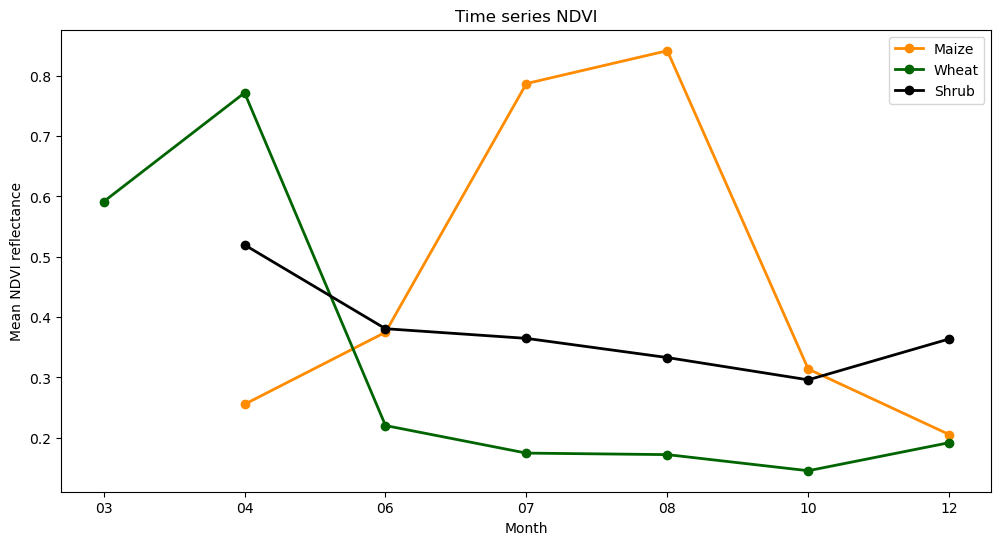

In [42]:
# Show
plt.figure(figsize=(12, 6))
# plt.plot(x, y, marker= type of marker, linestyle= type of line, color= color of line, linewidth= line thickness, label= tag for legend)

plt.plot(pivot_data.index, pivot_data['Maize'], marker='o', linestyle='-', color='darkorange', linewidth=2, label='Maize')
plt.plot(pivot_data.index, pivot_data['Wheat'], marker='o', linestyle='-', color='darkgreen', linewidth=2, label='Wheat')
plt.plot(pivot_data.index, pivot_data['Shrub'], marker='o', linestyle='-', color='black', linewidth=2, label='Shrub')
plt.legend()
plt.title(f'Time series {band_ind}')
plt.xlabel('Month')
plt.ylabel(f'Mean {band_ind} reflectance') 
plt.savefig('Time_series_NDVI.png', dpi=300, bbox_inches='tight') 
# plt.show()

### Time series of more land covers

In [46]:
# Copy the original dataframe
all_plots=ts.copy()
sp_list=['Barley','Fallow','Sunflower','Wheat','Shrub','Forest','Maize','Vineyard','Olive']
all_plots=all_plots.loc[all_plots.Species.isin(sp_list)]

In [47]:
# Calculate NDVI
all_plots['NDVI']=(all_plots['NIR'] - all_plots['Red']) / (all_plots['NIR'] + all_plots['Red'])

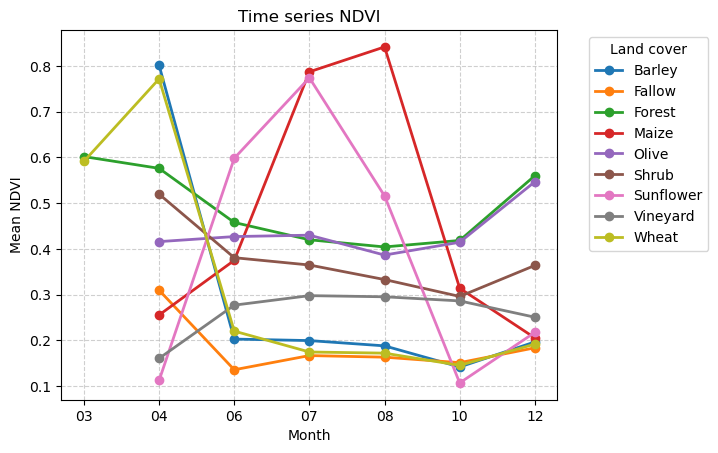

In [48]:
# Group by Month and Species
monthly_data = (all_plots.groupby(['Month', 'Species'])[band_ind].mean().reset_index().rename(columns={band_ind: 'Mean_Value'}))
# Restructure data
pivot_data = monthly_data.pivot_table(index='Month',columns='Species',values='Mean_Value')
pivot_data

pivot_data.plot(ax=plt.gca(),       #Use the current Matplotlib Axes object
    marker='o',         
    linestyle='-',
    linewidth=2
)

# Settings and labels
plt.title(f'Time series {band_ind}')
plt.xlabel('Month')
plt.ylabel(f'Mean {band_ind}')
plt.legend(title='Land cover', bbox_to_anchor=(1.05, 1), loc='upper left') # Mueve la leyenda fuera
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()
